In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib

clients=pd.read_csv('abandonament-telecom/clients.csv')
abandonament=pd.read_csv('abandonament-telecom/abandonament.csv')
internet=pd.read_csv('abandonament-telecom/internet.csv')

df=clients.merge(abandonament, on='customerID', how='outer') # unim
df=df.merge(internet, on='customerID', how='outer')

In [80]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Partner']=df['Partner'].map({'No': 0, 'Yes': 1})
df['Dependents']=df['Dependents'].map({'No': 0, 'Yes': 1})
df_nans = df[df['Partner'].isna()] # creem un nou dataframe amb el clients que no han especificat si tenen parella per analitzar més tard
df.dropna(inplace=True) # eliminem els NaNs de la columna Partner
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,...,TotalCharges,Churn,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,0,0,1.0,1,9,Yes,One year,Yes,Mailed check,...,,No,No,DSL,No,Yes,No,Yes,Yes,No
1,0003-MKNFE,1,0,0.0,0,9,Yes,Month-to-month,No,Mailed check,...,542.4,No,Yes,DSL,No,No,No,No,No,Yes
2,0004-TLHLJ,1,0,0.0,0,4,Yes,Month-to-month,Yes,Electronic check,...,280.85,Yes,No,Fiber optic,No,No,Yes,No,No,No
3,0011-IGKFF,1,1,1.0,0,13,Yes,Month-to-month,Yes,Electronic check,...,1237.85,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,0,1,1.0,0,3,Yes,Month-to-month,Yes,Mailed check,...,267.4,Yes,No,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,9987-LUTYD,0,0,0.0,0,13,Yes,One year,No,Mailed check,...,742.9,No,No,DSL,Yes,No,No,Yes,No,No
7038,9992-RRAMN,1,0,1.0,0,22,Yes,Month-to-month,Yes,Electronic check,...,1873.7,Yes,Yes,Fiber optic,No,No,No,No,No,Yes
7039,9992-UJOEL,1,0,0.0,0,2,Yes,Month-to-month,Yes,Mailed check,...,,No,No,DSL,No,Yes,No,No,No,No
7040,9993-LHIEB,1,0,1.0,1,67,Yes,Two year,No,Mailed check,...,4627.65,No,No,DSL,Yes,No,Yes,Yes,No,Yes


Creem una nova columna amb el numero de serveis contractacts per a cada client, anomenada total_serveis

In [82]:
cols_serveis = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['total_serveis'] = df[cols_serveis].apply(lambda row: sum(x == 'Yes' for x in row), axis=1)
df['total_serveis'] = df['total_serveis'] + df['InternetService'].apply(lambda x: 1 if x in ['DSL', 'Fiber optic'] else 0)
df['total_serveis'] = df['total_serveis'] + df['MultipleLines'].apply(lambda x: 1 if x == 'Yes' else 0)

t-students test per comparar les mitjanes de total_serveis segons les categories: seniors, genere, dependents i parella.

In [84]:
from scipy.stats import ttest_ind

# Variables a analitzar
variables = ['SeniorCitizen', 'gender', 'Partner', 'Dependents']

# Resultats del test t
for var in variables:
    grup0 = df[df[var] == 0]['total_serveis']
    grup1 = df[df[var] == 1]['total_serveis']

    stat, p = ttest_ind(grup0, grup1, equal_var=False) # assumim que les dues mostres no tenen la mateixa variància. Es realitza un t-test de Welch 
    
    mitjana0 = grup0.mean()
    mitjana1 = grup1.mean()
    diferencia = mitjana1 - mitjana0
    print(f"{var}: mitjana0={mitjana0:.2f}, mitjana1={mitjana1:.2f}, diferència de mitjanes = {diferencia:.2f}, p-valor = {p:.3f}")

SeniorCitizen: mitjana0=3.11, mitjana1=3.85, diferència de mitjanes = 0.74, p-valor = 0.000
gender: mitjana0=3.25, mitjana1=3.21, diferència de mitjanes = -0.04, p-valor = 0.507
Partner: mitjana0=2.80, mitjana1=3.70, diferència de mitjanes = 0.90, p-valor = 0.000
Dependents: mitjana0=3.24, mitjana1=3.21, diferència de mitjanes = -0.04, p-valor = 0.594


Els sèniors i els clients amb parella contracten significativament més serveis.
El gènere i tenir dependents no mostren diferències estadísticament significatives.

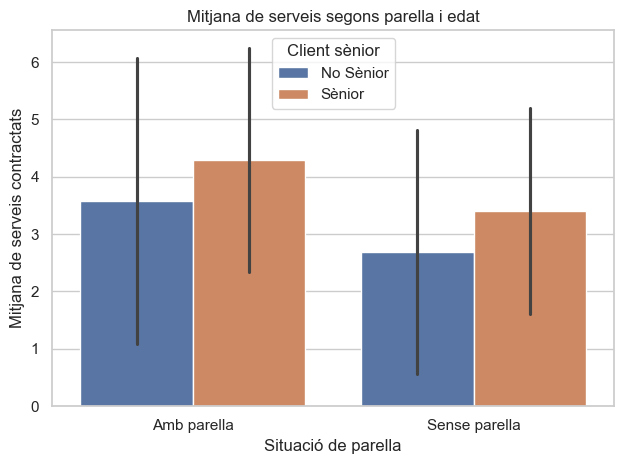

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.barplot(
    data=df,
    x=df['Partner'].map({0: 'Sense parella', 1: 'Amb parella'}),
    y='total_serveis',
    hue=df['SeniorCitizen'].map({0: 'No Sènior', 1: 'Sènior'}),
    errorbar='sd'
)

plt.title('Mitjana de serveis segons parella i edat')
plt.xlabel('Situació de parella')
plt.ylabel('Mitjana de serveis contractats')
plt.legend(title='Client sènior')
plt.tight_layout()
plt.show()


In [87]:
# Resultats del test t
print("Relació variables demografiques vs permanencia:")
for var in variables:
    grup0 = df[df[var] == 0]['tenure']
    grup1 = df[df[var] == 1]['tenure']

    stat, p = ttest_ind(grup0, grup1, equal_var=False)
    
    mitjana0 = grup0.mean()
    mitjana1 = grup1.mean()
    diferencia = mitjana1 - mitjana0
    print(f"{var}: mitjana0={mitjana0:.2f}, mitjana1={mitjana1:.2f}, diferència de mitjanes = {diferencia:.2f}, p-valor = {p:.3f}")

Relació variables demografiques vs permanencia:
SeniorCitizen: mitjana0=32.06, mitjana1=33.35, diferència de mitjanes = 1.28, p-valor = 0.118
gender: mitjana0=31.97, mitjana1=32.57, diferència de mitjanes = 0.60, p-valor = 0.334
Partner: mitjana0=23.22, mitjana1=41.91, diferència de mitjanes = 18.68, p-valor = 0.000
Dependents: mitjana0=29.68, mitjana1=38.33, diferència de mitjanes = 8.66, p-valor = 0.000


Tenir parella i dependents afavoreix clarament la permanència a l'empresa

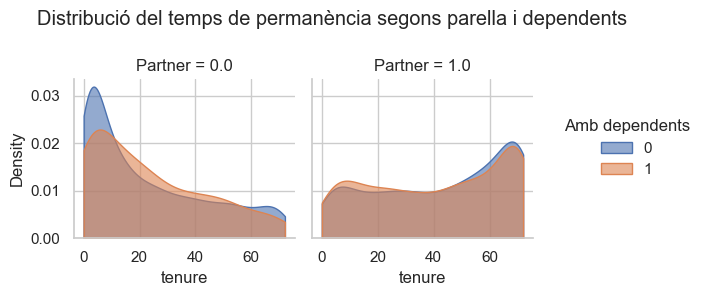

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definim el límit superior de tenure per ajustar el KDE
tenure_max = df['tenure'].max()

# Creem el FacetGrid amb columnes segons si tenen parella
g = sns.FacetGrid(df, col="Partner", hue="Dependents", margin_titles=True)

# Dibuixem les corbes KDE amb clip per evitar valors negatius
g.map(sns.kdeplot, "tenure", fill=True, common_norm=False, alpha=0.6, clip=(0, tenure_max)) # aqui afegim clip pq no volem probabilitats de tenure negatius 

# Ajustem llegenda i títol
g.add_legend(title="Amb dependents")
g.fig.subplots_adjust(top=0.75)
g.fig.suptitle("Distribució del temps de permanència segons parella i dependents")

plt.show()

chi-quadrada -> per comparar la frequencia 

In [91]:
from scipy.stats import chi2_contingency
for var in variables:
    taula = pd.crosstab(df[var], df['Churn'])
    chi2, p, gdl, expected = chi2_contingency(taula)
    print(f"{var}: Chi² = {chi2:.2f}, p-valor = {p:.5f}")

SeniorCitizen: Chi² = 155.32, p-valor = 0.00000
gender: Chi² = 0.28, p-valor = 0.59755
Partner: Chi² = 146.96, p-valor = 0.00000
Dependents: Chi² = 199.43, p-valor = 0.00000


moltes variables significatives -> dificil de representar